# SurgeSense: An Early Warning System for Patient Surges

# Business Understanding

## Background

The AIC Kijabe Hospital is located in Kiambu county, Kenya. It was founded in 1915 as a small outpatient clinic, with the goal of serving the local community. Today, it has transformed into one of the preeminent referral and teaching hospitals in Kenya. It is a Level VI National Tertiary Teaching and Referral hospital, with a 363 bed capacity, and over 900 staff members. It is the largest of five hospitals sponsored by the AIC networks across Kenya, and serves patients from across the country as well as neighbouring African nations. The hospital also offers specialized care, including 15 operating rooms, a 24-hour emergency casualty department, adult and paediatric intensive care units (ICUs), and dedicated oncology, dental and eye clinics.

## Problem Statement

The AIC Kijabe hospital's outpatient department (OPD) currently manages patient flow across approximately forty departments (General OPD, Casualty, Renal, Oncology, and others) without a structured way to anticipate periods of high patient volume. This can lead to under-staffing during surges and inefficient resource allocation during quieter periods. Additionally, no formal analysis exists on how patient volume and return differs across departments, which limits the hospital’s ability to plan follow up care capacity.

## Research Questions

Can daily patient volume in the OPD be forecast accurately per department, in order to support staffing decisions and resource allocation?


## Business Objectives
- To enable the hospital to anticipate periods of higher patient volume in advance, so that staffing and resources can be planned proactively rather than reactively.
- To understand patient return behavior (how long patients typically go before returning to the hospital) to support follow-up care planning.

## Specific Objectives  

- To build and evaluate regression models to forecast daily patient volume for the hospital’s high volume departments. 
- To identify which features most strongly predict patient volume per department. 

## Data Analysis Goals 

- To build a time series forecasting model to predict daily department-level patient arrival volume.
- To quantify the relationship between seasonal patterns and patient volume, including any lagged effects.
- To apply survival analysis to model time-to-return-visit, since discharge/exit data is not available in this dataset, return-visit interval is used as a signal for patient care continuity.

## Success Metrics for Prediction 

Success for this project will be defined against measurable targets.
- Mean Absolute Error (MAE) - The model will be evaluated using Mean Absolute Error, which measures the average absolute difference between the actual and predicted number of patients.
- Root Mean Squared Error (RMSE) - Root Mean Squared Error will be used to assess the magnitude of prediction errors while giving greater weight to larger errors.
- Mean Absolute Percentage Error (MAPE) - Mean Absolute Percentage Error will be used to measure prediction error as a percentage, providing a measure of the model's forecasting accuracy across different levels of patient demand.
- Coefficient of Determination (R²) - The coefficient of determination will be used to determine how well the model explains variations in daily patient volume.


# Data Preparation

In [1]:
#%pip install openpyxl

In [2]:
%pip install XGBoost

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
# import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# load the data
data = pd.read_excel("Opd_data.xlsx")
data.head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
0,010575758,2024-06-01 00:00:00.000,Male,38 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW )
1,010575713,2024-06-01 00:00:00.000,Female,29 Yr(s),NaN,NaN
2,010569291,2024-06-01 00:04:38.083,Female,44 Yr(s),GENERAL OPD,General Outpatient Care
3,010575732,2024-06-01 00:04:42.460,Female,78 Yr(s),GENERAL OPD,General Outpatient Care
4,010575731,2024-06-01 00:10:16.037,Female,2 Yr(s),ADMISSION,Admission


In [6]:
# Basic exploratory
data.shape
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 306306 entries, 0 to 306305
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   PatientNumber       306306 non-null  str           
 1   RegistrationDate    306306 non-null  datetime64[us]
 2   Gender              306291 non-null  str           
 3   Age                 305735 non-null  str           
 4   QueuedTo            299528 non-null  str           
 5   ConsultDescription  299920 non-null  str           
dtypes: datetime64[us](1), str(5)
memory usage: 14.0 MB
None


## Data Cleaning

In [7]:
# Check for missing values
data.isnull().sum()

PatientNumber            0
RegistrationDate         0
Gender                  15
Age                    571
QueuedTo              6778
ConsultDescription    6386
dtype: int64

In [8]:
# check for duplicates
data.duplicated().sum()

np.int64(355)

In [9]:
# Drop the duplicates
data= data.drop_duplicates()

In [10]:
# Recheck for duplicates
data.duplicated().sum()

np.int64(0)

In [11]:
# Drop gender null values
data = data[data['Gender'].notna()]

In [12]:
# Standardize casing
data['Gender'] = data['Gender'].str.strip().str.upper()

## Age In Years

In [13]:
# extract the number and the unit separately
data['AgeNum'] = data['Age'].str.extract(r'(\d+)').astype(float)
# the numeric part, 38
data['AgeUnit'] = data['Age'].str.extract(r'\d+\s*(\D+)')[0].str.strip()  
# the unit part, "Yr(s)"

# convert based on unit: years stay the same, months divide by 12, weeks divide by 52, days divide by 365
conditions = [
    data['AgeUnit'] == 'Yr(s)',
    data['AgeUnit'] == 'Mth(s)',
    data['AgeUnit'] == 'Week(s)',
    data['AgeUnit'] == 'Days(s)'
]
choices = [
    data['AgeNum'],
    data['AgeNum'] / 12,
    data['AgeNum'] / 52,
    data['AgeNum'] / 365
]
data['AgeYears'] = np.select(conditions, choices, default=np.nan)

# round to 2 decimal places
data['AgeYears'] = data['AgeYears'].round(2)  

# only interested in age years
data = data.drop(columns=['AgeNum', 'AgeUnit'])


In [14]:
# Turning all impossible ages (>100)into NAN
data.loc[data['AgeYears'] > 100, 'AgeYears'] = np.nan

In [15]:
# calculate the mean age from all remaining valid values (this naturally excludes 
# both the >100 values we just nulled and any age that was already missing)
mean_age = round(data['AgeYears'].mean(), 2)
print(round(mean_age, 2))

40.86


In [16]:
# impute missing ages with mean
data['AgeYears'] = data['AgeYears'].fillna(mean_age)

print(mean_age)
# print(data['Age_num'].isna().sum())
print(data['AgeYears'].isna().sum())

40.86
0


In [17]:
# Bin into ages groups
data['AgeGroup']  = pd.cut(
    data['AgeYears'],                                    
    bins=[0,5,12,18,35,60,100],
    labels=['Infant(0-5)','Child(6-12)','Teen(13-18)','Young Adult(19-35)','Adult(36-60)','Senior(61-100)'],
    include_lowest=True
)

In [18]:
# Drop missing QueuedTo
data = data.dropna(subset=['QueuedTo'])

In [19]:
# Clean the QueuedTo column
data['QueuedTo']= data['QueuedTo'].str.strip().str.upper()

In [20]:
# Drop the age column
data = data.drop(columns=['Age'])

In [21]:
# Rechecking the null values
data.isna().sum()

PatientNumber         0
RegistrationDate      0
Gender                0
QueuedTo              0
ConsultDescription    0
AgeYears              0
AgeGroup              0
dtype: int64

In [22]:
data[data['AgeGroup'].isna()]['AgeYears'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: AgeYears, dtype: float64

In [23]:
data['AgeGroup'].unique()

['Adult(36-60)', 'Senior(61-100)', 'Infant(0-5)', 'Young Adult(19-35)', 'Child(6-12)', 'Teen(13-18)']
Categories (6, str): ['Infant(0-5)' < 'Child(6-12)' < 'Teen(13-18)' < 'Young Adult(19-35)' < 'Adult(36-60)' < 'Senior(61-100)']

In [24]:
# Recheck everything
print("Shape:", data.shape)
print()
print("Missing values:")
print(data.isnull().sum())
print()
print("Duplicate rows:", data.duplicated().sum())
print()
print("Dtypes:")
print(data.dtypes)
print()
print("Age range check:", data['AgeYears'].min(), "-", data['AgeYears'].max())
## print("Age range check:", data['Age_num'].min(), "-", data['Age_num'].max())
print()
print("Columns:", list(data.columns))

Shape: (299162, 7)

Missing values:
PatientNumber         0
RegistrationDate      0
Gender                0
QueuedTo              0
ConsultDescription    0
AgeYears              0
AgeGroup              0
dtype: int64

Duplicate rows: 0

Dtypes:
PatientNumber                    str
RegistrationDate      datetime64[us]
Gender                           str
QueuedTo                         str
ConsultDescription               str
AgeYears                     float64
AgeGroup                    category
dtype: object

Age range check: 0.0 - 100.0

Columns: ['PatientNumber', 'RegistrationDate', 'Gender', 'QueuedTo', 'ConsultDescription', 'AgeYears', 'AgeGroup']


# Data Exploration

In [25]:
# Exploring the data
data['QueuedTo'].unique()

<StringArray>
[                        'GENERAL OPD',                           'ADMISSION',
                            'CASUALTY',                        'GEN SURG OPD',
                               'RENAL',                                 'MCH',
                       'PHYSIOTHERAPY',                             'DAYCASE',
                              'DENTAL',                   'SPECIALITY CLINIC',
                          'PSYCHOLOGY',                                'OHNS',
                            'ONCOLOGY',                      'PRIVATE CLINIC',
                          'EYE CLINIC',                          'PAEDS BKKH',
 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)',                           'ORTHO OPD',
                          'PALLIATIVE',                           'AUDIOLOGY',
                           'NUTRITION',                'OCCUPATIONAL THERAPY',
          'NEURO SURGERY CONSULTATION',                     'FAMILY MEDICINE',
                     'DIABETIC CLINIC'

In [26]:
data['QueuedTo'].value_counts(dropna=False)

QueuedTo
GENERAL OPD                            85620
ADMISSION                              33876
MCH                                    29451
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    25365
SPECIALITY CLINIC                      22356
ONCOLOGY                               13606
MEB SPECIALITY CLINIC                  13523
RENAL                                  11103
PAEDS BKKH                              9731
DENTAL                                  9252
DAYCASE                                 7596
OHNS                                    7290
EYE CLINIC                              6026
PHYSIOTHERAPY                           5825
GEN SURG OPD                            5155
CASUALTY                                3460
PRIVATE CLINIC                          3075
AUDIOLOGY                               1379
PSYCHOLOGY                              1223
NEUROSURGERY                            1032
OCCUPATIONAL THERAPY                     815
NUTRITION                                752
T

In [27]:
# 1. Drop the 3 one-off data errors
data = data[~data['QueuedTo'].isin(['KJ000104/19', 'Naivasha Town Clinic', 'All'])]

# 2. Flag admissions separately (so you can exclude/include as needed per analysis)
data['IsAdmission'] = data['QueuedTo'] == 'ADMISSION'


In [28]:
# Feature engineering
data['DayOfWeek'] = data['RegistrationDate'].dt.day_name()
data['IsWeekend'] = data['RegistrationDate'].dt.dayofweek >= 5
data['Month'] = data['RegistrationDate'].dt.month_name()
data['Date'] = data['RegistrationDate'].dt.date
data['Year'] = data['RegistrationDate'].dt.year
data['Hour'] = data['RegistrationDate'].dt.hour

data[['RegistrationDate', 'DayOfWeek', 'IsWeekend', 'Month', 'Hour', 'Year', 'Date']].head()

,RegistrationDate,DayOfWeek,IsWeekend,Month,Hour,Year,Date
0,2024-06-01 00:00:00.000,Saturday,True,June,0,2024,2024-06-01
2,2024-06-01 00:04:38.083,Saturday,True,June,0,2024,2024-06-01
3,2024-06-01 00:04:42.460,Saturday,True,June,0,2024,2024-06-01
4,2024-06-01 00:10:16.037,Saturday,True,June,0,2024,2024-06-01
5,2024-06-01 01:22:53.050,Saturday,True,June,1,2024,2024-06-01


In [29]:
# confirm this is ok
print(data.shape)
print(data.isna().sum())

(299161, 14)
PatientNumber         0
RegistrationDate      0
Gender                0
QueuedTo              0
ConsultDescription    0
AgeYears              0
AgeGroup              0
IsAdmission           0
DayOfWeek             0
IsWeekend             0
Month                 0
Date                  0
Year                  0
Hour                  0
dtype: int64


In [30]:
# Top 5 deparrtments, everything else grouped others
Top_Departments = [
    'GENERAL OPD',
    'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)',
    'MCH',
    'SPECIALITY CLINIC',
    'ONCOLOGY',
    'RENAL',
]

data['QueuedTo_Grouped'] = data['QueuedTo'].where(
    data['QueuedTo'].isin(Top_Departments)
)

data['QueuedTo_Grouped'].value_counts()

QueuedTo_Grouped
GENERAL OPD                            85620
MCH                                    29451
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    25365
SPECIALITY CLINIC                      22356
ONCOLOGY                               13606
RENAL                                  11103
Name: count, dtype: int64

In [31]:
# Exclude admission completely
data_opd_only = data[~data['IsAdmission']]

In [32]:
data.info()

<class 'pandas.DataFrame'>
Index: 299161 entries, 0 to 306305
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   PatientNumber       299161 non-null  str           
 1   RegistrationDate    299161 non-null  datetime64[us]
 2   Gender              299161 non-null  str           
 3   QueuedTo            299161 non-null  str           
 4   ConsultDescription  299161 non-null  str           
 5   AgeYears            299161 non-null  float64       
 6   AgeGroup            299161 non-null  category      
 7   IsAdmission         299161 non-null  bool          
 8   DayOfWeek           299161 non-null  str           
 9   IsWeekend           299161 non-null  bool          
 10  Month               299161 non-null  str           
 11  Date                299161 non-null  object        
 12  Year                299161 non-null  int32         
 13  Hour                299161 non-null  int32   

## EDA

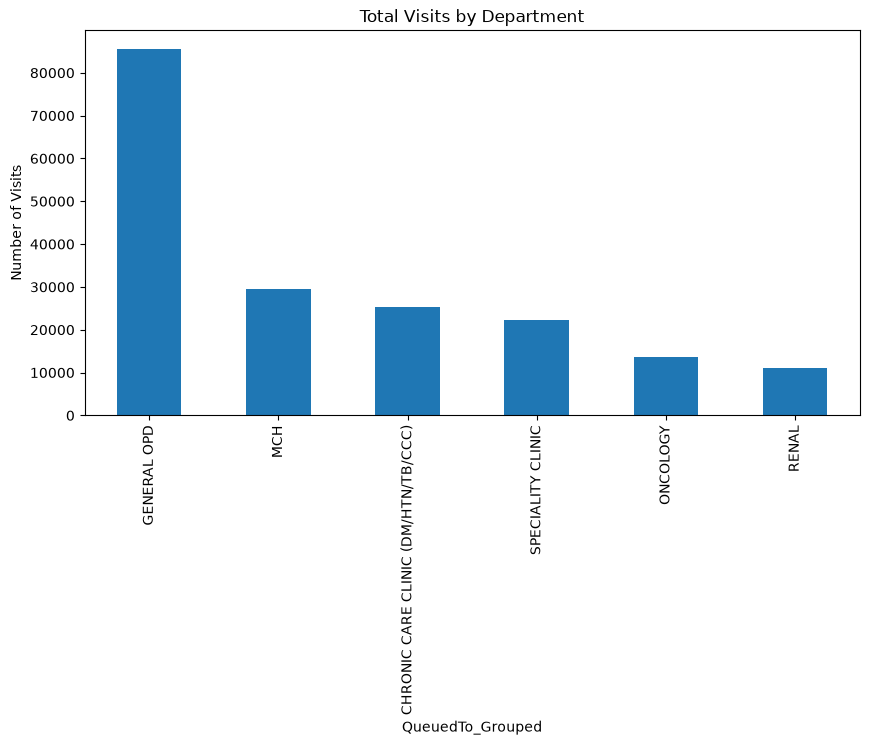

In [33]:
# Total visit volume by department
Total_dept = data['QueuedTo_Grouped'].value_counts()
Total_dept.plot(kind='bar', figsize=(10,5), title='Total Visits by Department')
plt.ylabel('Number of Visits')
plt.show()

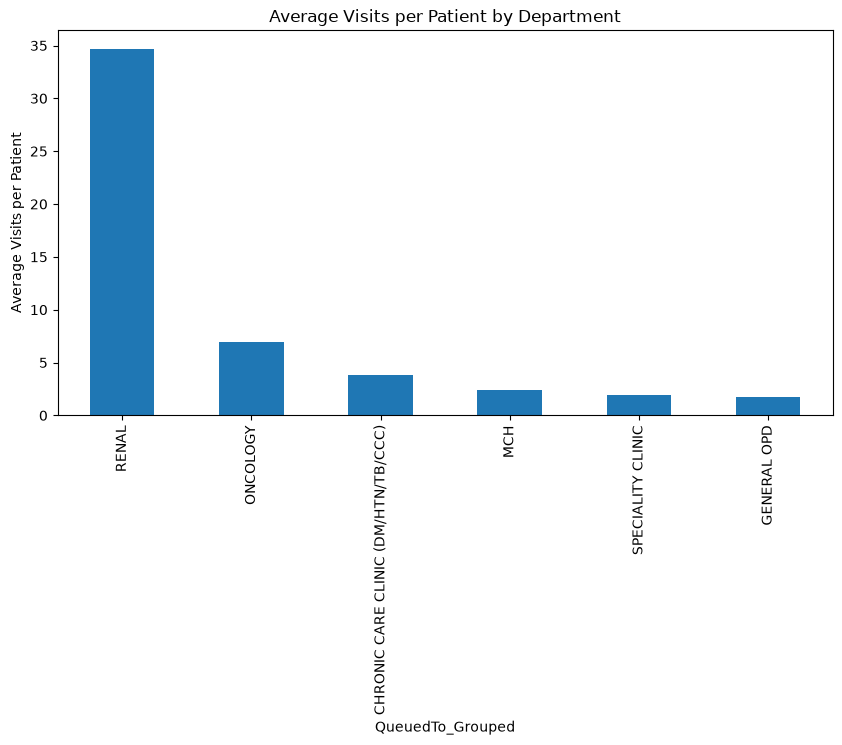

QueuedTo_Grouped
RENAL                                  34.696875
ONCOLOGY                                6.956033
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)     3.832729
MCH                                     2.422156
SPECIALITY CLINIC                       1.939951
GENERAL OPD                             1.742227
Name: visits, dtype: float64

In [34]:
# Average visits per patient,by department
visits_per_patient_by_dept = data.groupby(['QueuedTo_Grouped', 'PatientNumber']).size().reset_index(name='visits')
avg_visits_by_dept = visits_per_patient_by_dept.groupby('QueuedTo_Grouped')['visits'].mean().sort_values(ascending=False)

avg_visits_by_dept.plot(kind='bar', figsize=(10,5), title='Average Visits per Patient by Department')
plt.ylabel('Average Visits per Patient')
plt.show()

avg_visits_by_dept

#### Observation
Renal patients has the highest number of repeated visits more than any departments,followed by chronic care clinic

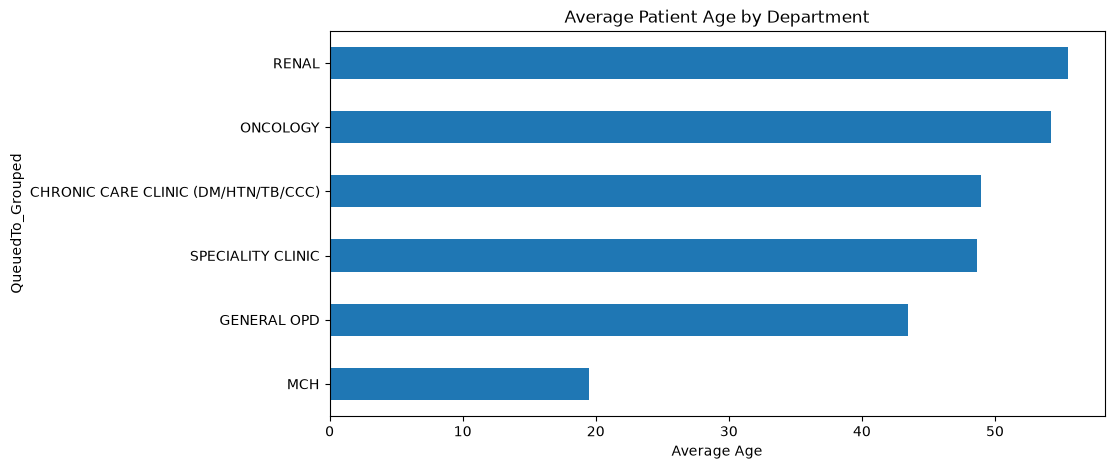

In [35]:
# Average patient age by department

# avg_age_by_dept = data.groupby('QueuedTo_Grouped')['Age_num'].mean().sort_values()
avg_age_by_dept = data.groupby('QueuedTo_Grouped')['AgeYears'].mean().sort_values()
avg_age_by_dept.plot(kind='barh', figsize=(10,5), title='Average Patient Age by Department')
plt.xlabel('Average Age')
plt.show()

### Observation
Average patient age varies meaningfully by department, from 22 years in Maternal Child Health to 56 years in renal.

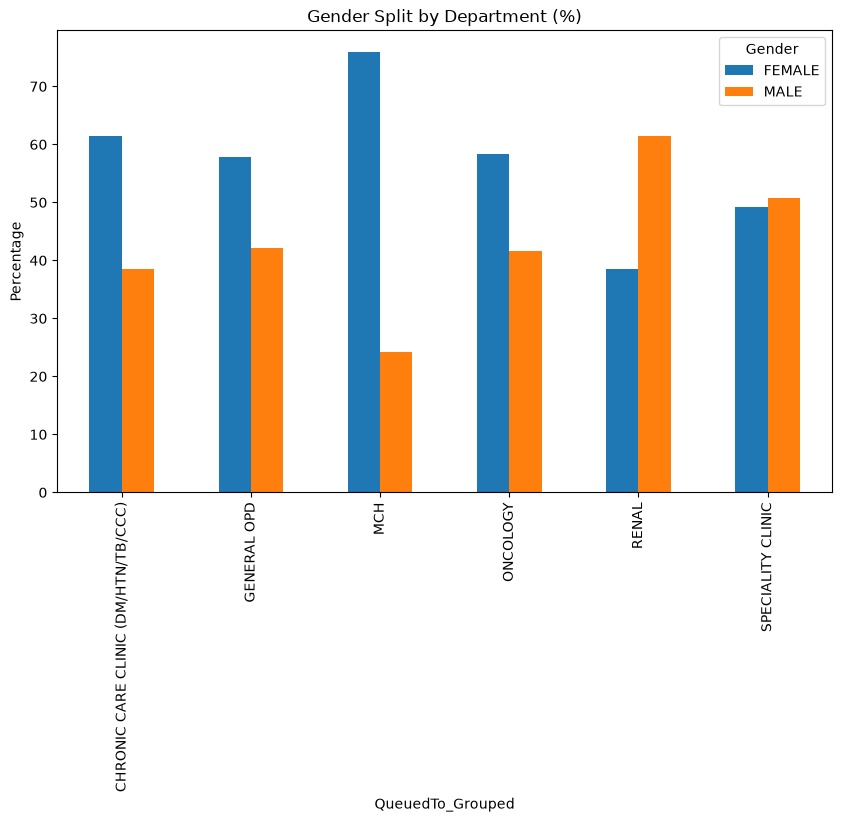

In [36]:
gender_by_dept = pd.crosstab(data['QueuedTo_Grouped'], data['Gender'], normalize='index') * 100
gender_by_dept.plot(kind='bar', stacked=False, figsize=(10,6), title='Gender Split by Department (%)')
plt.ylabel('Percentage')
plt.show()

#### Observation
Gender distribution across departments aligns with expected clinical patterns — MCH shows a strong female skew consistent with maternal care, while other departments show a mild, broadly consistent female-leaning skew in line with general healthcare utilization trends.Renal has the highest percentaage of male patients.


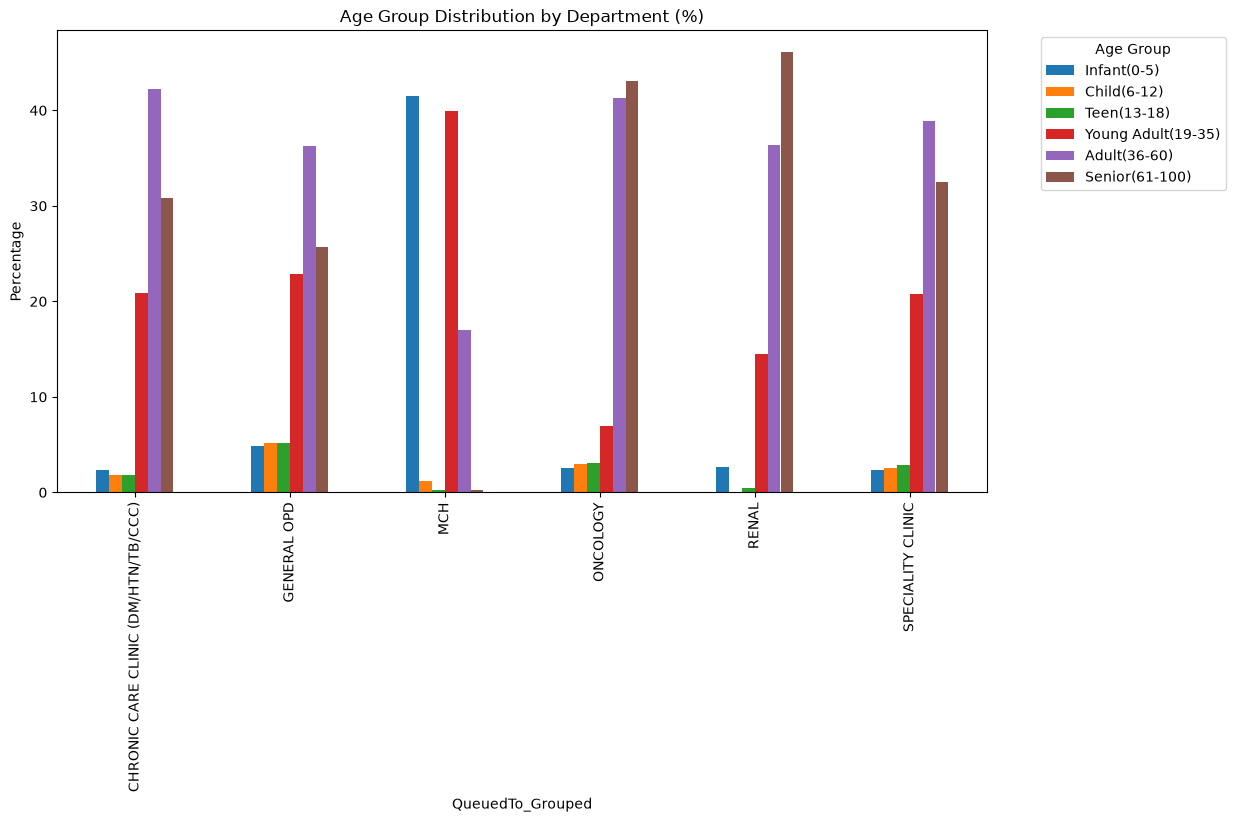

AgeGroup,Infant(0-5),Child(6-12),Teen(13-18),Young Adult(19-35),Adult(36-60),Senior(61-100)
QueuedTo_Grouped,,,,,,
CHRONIC CARE CLINIC (DM/HTN/TB/CCC),2.385176,1.825350,1.852947,20.855510,42.270846,30.810171
GENERAL OPD,4.841159,5.179865,5.179865,22.882504,36.276571,25.640037
MCH,41.529999,1.174833,0.203728,39.903569,16.987539,0.200333
ONCOLOGY,2.594444,2.925180,3.116272,6.974864,41.334705,43.054535
RENAL,2.665946,0.000000,0.414302,14.509592,36.341529,46.068630
SPECIALITY CLINIC,2.361782,2.594382,2.849347,20.764001,38.884416,32.546073


In [37]:
# Age group distribution by department
age_group_by_dept = pd.crosstab(data['QueuedTo_Grouped'], data['AgeGroup'], normalize='index') * 100
age_group_by_dept.plot(kind='bar', stacked=False, figsize=(12,6), title='Age Group Distribution by Department (%)')
plt.ylabel('Percentage')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1))
plt.show()

age_group_by_dept

#### Observation
Age distribution varies sharply and predictably by department — MCH is dominated by infants and young adult mothers, while Oncology, Renal and Chronic Care skew heavily toward adults and seniors, consistent with known age-related disease patterns. This confirms our department groupings reflect real clinical distinctions, not arbitrary categories.

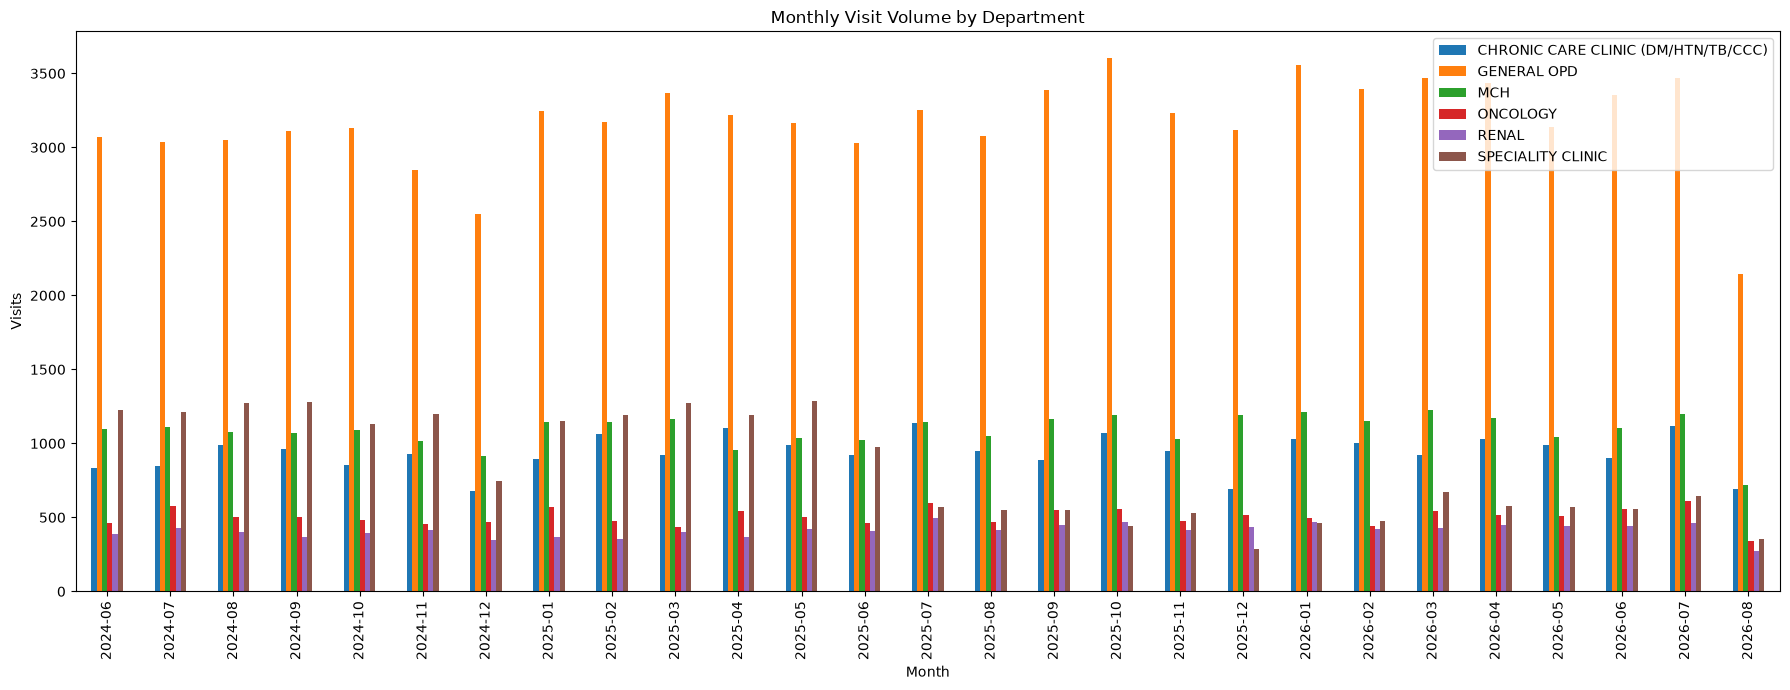

In [38]:
# monthly volume
daily_by_dept = data.groupby(['QueuedTo_Grouped', data['RegistrationDate'].dt.date]).size().reset_index(name='visit_count')
daily_by_dept.rename(columns={'RegistrationDate':'date'}, inplace=True)
daily_by_dept['date'] = pd.to_datetime(daily_by_dept['date'])

# get monthly counts from aggregating daily ones
daily_by_dept['MonthYear'] = daily_by_dept['date'].dt.to_period('M')
monthly_by_dept = daily_by_dept.groupby(['MonthYear', 'QueuedTo_Grouped'])['visit_count'].sum().unstack()
monthly_by_dept.index = monthly_by_dept.index.astype(str)

# Plot the grouped monthly bars
monthly_by_dept.plot(kind='bar', figsize=(18,7))
plt.title('Monthly Visit Volume by Department')
plt.xlabel('Month')
plt.ylabel('Visits')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Observation
Departments fall into two distinct volume tiers.GENERAL OPD consistently record the highest daily volumes and show a clear upward trend over the 2024–2026 period, while Chronic Care Clinic, MCH, Oncology, and Speciality Clinic remain comparatively lower in volume but more stable and consistent over time. This validates our decision to forecast high-volume departments individually rather than treating hospital-wide demand as a single uniform metric.

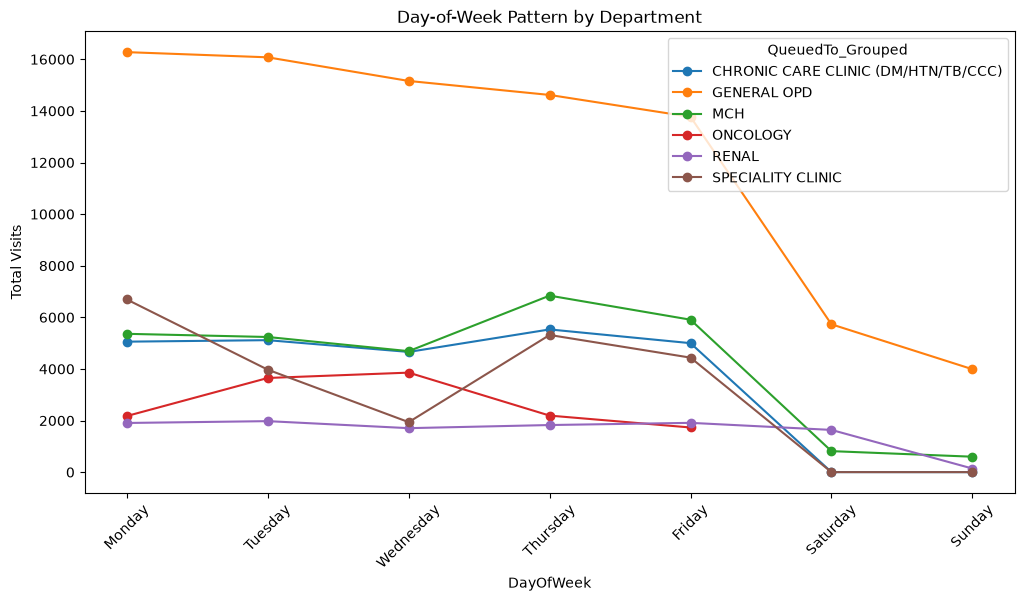

In [39]:
# Day of the week pattern,by department
data['DayOfWeek'] = data['RegistrationDate'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_by_dept = data.groupby(['QueuedTo_Grouped', 'DayOfWeek']).size().unstack()[day_order]

dow_by_dept.T.plot(figsize=(12,6), marker='o', title='Day-of-Week Pattern by Department')
plt.ylabel('Total Visits')
plt.xticks(rotation=45)
plt.show()

#### Observation
Visit volume shows a strong, near-binary weekday/weekend divide across all departments GENERAL OPD and MCH consistently record the highest weekday volumes, together accounting for the majority of total OPD traffic, while Chronic Care Clinic, MCH, Oncology, Renal and Speciality Clinic maintain lower but stable weekday volumes.

Weekend volume collapses sharply across nearly all departments, with Chronic Care, MCH, Oncology, and Speciality Clinic dropping to near-zero - indicating these are likely scheduled, appointment-based clinics that do not operate on weekends. General OPD, by contrast, retains a modest but non-zero weekend presence, suggesting it functions as the hospital's primary walk-in/emergency-adjacent service even outside standard weekday hours.

Notably, MCH peaks toward the end of the week (Wednesday-Thursday) before its weekend drop, while General OPD peaks early (Monday) and gradually declines - indicating these two largest departments follow distinct weekly rhythms rather than moving in tandem, despite both representing high-traffic, general-access care.

In [40]:
# Variability comparison- which depaerment is the hardest to predict
daily_stats_by_dept = daily_by_dept.groupby('QueuedTo_Grouped')['visit_count'].agg(['mean', 'std'])
daily_stats_by_dept['coefficient_of_variation'] = daily_stats_by_dept['std'] / daily_stats_by_dept['mean']
daily_stats_by_dept.sort_values('coefficient_of_variation', ascending=False)

,mean,std,coefficient_of_variation
QueuedTo_Grouped,,,
MCH,36.359259,22.714721,0.624730
SPECIALITY CLINIC,41.865169,25.037544,0.598052
GENERAL OPD,105.703704,45.935233,0.434566
ONCOLOGY,24.471223,10.399977,0.424988
CHRONIC CARE CLINIC (DM/HTN/TB/CCC),45.213904,12.171126,0.269190
RENAL,15.399445,3.987648,0.258947


### Observation
-Chronic Care Clinic and Renal are by far the most predictable department (0.26 - 0.27) — their daily volume barely fluctuates relative to their average. This makes sense: chronic care and renal are appointment-driven and scheduled in advance, not walk-in, so it doesn't experience sudden surges or drops.
-MCH is the least predictable (0.62), followed closely by Speciality Clinic (0.60) and and GENERAL OPD(0.43) — these departments experience the most day-to-day volatility relative to their size.


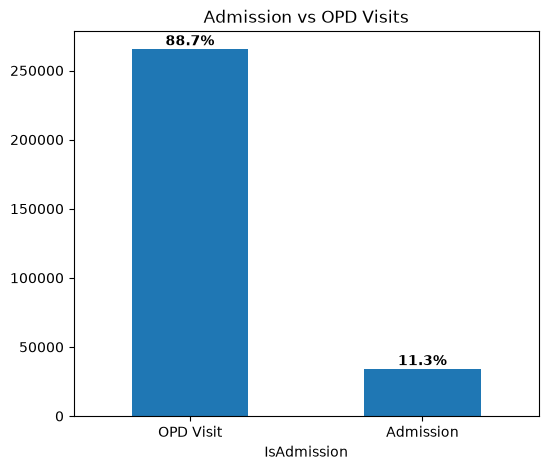

Admissions: 33876 (11.3%)


In [41]:
# Admission vs True opd volume comparison 
admission_summary = data.groupby('IsAdmission').size()

ax = admission_summary.plot(kind='bar', figsize=(6,5), title='Admission vs OPD Visits')  # <-- must have "ax =" here
plt.xticks([0,1], ['OPD Visit', 'Admission'], rotation=0)

total = admission_summary.sum()
for i, count in enumerate(admission_summary):
    pct = count / total * 100
    ax.text(i, count + total*0.01, f'{pct:.1f}%', ha='center', fontweight='bold')

plt.show()

print(f"Admissions: {admission_summary[True]} ({admission_summary[True]/len(data)*100:.1f}%)")

#### Observation
Reading the numbers: roughly 265,000 OPD visits vs. ~33,874 admissions -  meaning about 88% of all patient contacts at Kijabe are outpatient visits that don't result in admission, while only around 12% escalate to a full admission.

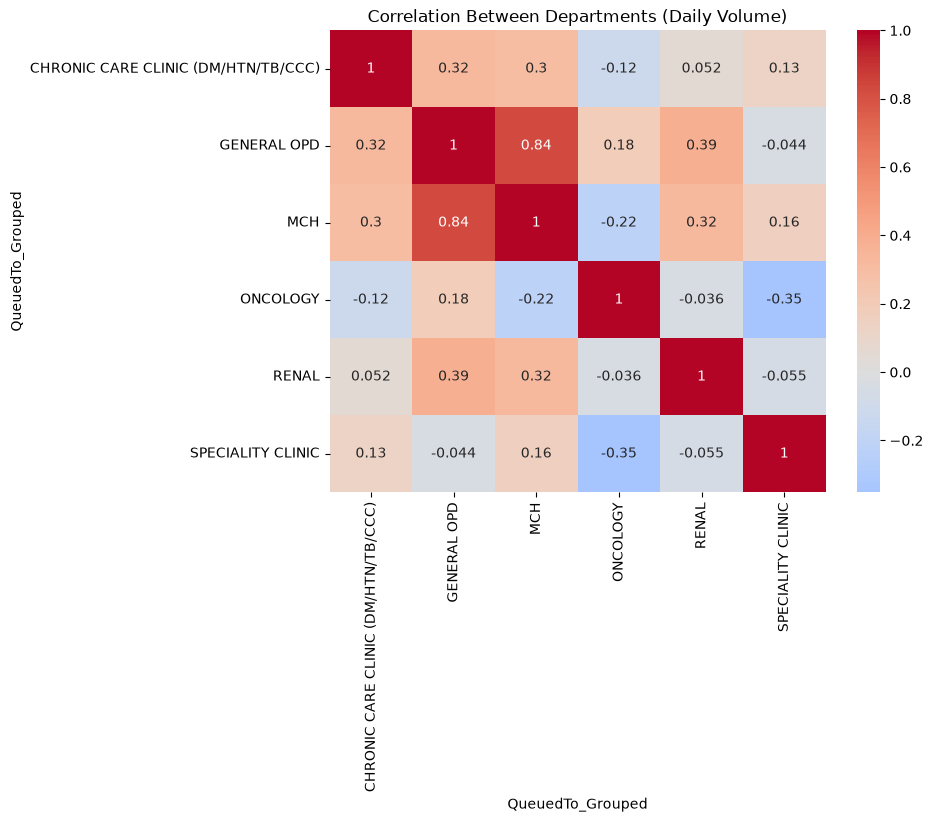

In [42]:
# Correlation between departments-do they rise or fall together
daily_pivot = daily_by_dept.pivot(index='date', columns='QueuedTo_Grouped', values='visit_count')
correlation_matrix = daily_pivot.corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Departments (Daily Volume)')
plt.show()

#### Observation
Departmental correlation analysis reveals two distinct clusters. General OPD and MCH show strong co-movement (r = 0.82–0.89), indicating shared, hospital-wide drivers of daily volume — most likely day-of-week and overall walk-in patient flow — rather than department-specific causes.These are strong positive correlations, meaning: when General OPD has a busy day, MCH is very likely busy that same day too.

In contrast, Chronic Care Clinic shows only moderate correlation (r ≈ 0.3) with this cluster, consistent with its appointment-driven, rather than walk-in-driven, nature. Oncology, Renal and Speciality Clinic show weak or negative correlations with other departments, suggesting they operate on independent, fixed clinic schedules largely decoupled from general OPD demand.

In [43]:
# Summary table
summary = pd.DataFrame({
    'Total_Visits': data['QueuedTo_Grouped'].value_counts(),
    'Distinct_Patients': data.groupby('QueuedTo_Grouped')['PatientNumber'].nunique(),
    'Avg_Age': data.groupby('QueuedTo_Grouped')['AgeYears'].mean(),
    'Avg_Visits_per_Patient': avg_visits_by_dept,
})
summary['Visits_per_Patient_Rank'] = summary['Avg_Visits_per_Patient'].rank(ascending=False)
summary.sort_values('Total_Visits', ascending=False)

,Total_Visits,Distinct_Patients,Avg_Age,Avg_Visits_per_Patient,Visits_per_Patient_Rank
QueuedTo_Grouped,,,,,
GENERAL OPD,85620,49144,43.498928,1.742227,6.0
MCH,29451,12159,19.479803,2.422156,4.0
CHRONIC CARE CLINIC (DM/HTN/TB/CCC),25365,6618,48.980467,3.832729,3.0
SPECIALITY CLINIC,22356,11524,48.669860,1.939951,5.0
ONCOLOGY,13606,1956,54.204547,6.956033,2.0
RENAL,11103,320,55.468687,34.696875,1.0


### Observation
-Renal has the highest average visits per patient by far — 34.69 visits per patient, ranked #1. Despite being your smallest department by total visits (11,103) and having the fewest distinct patients (320), each Renal patient returns nearly 35 times on average. This is a dramatic, clear finding.
-Oncology ranks #2, at 6.96 visits per patient — also strong evidence of recurring/0ncology patient behavior, exactly matching your project's core hypothesis.
General OPD has the LOWEST visits per patient (1.74), ranked last (#6) — despite having the most total visits (85,620) and the most distinct patients (49,144). This means General -OPD's high volume comes from serving many different one-time/occasional patients, not from repeat vistors.

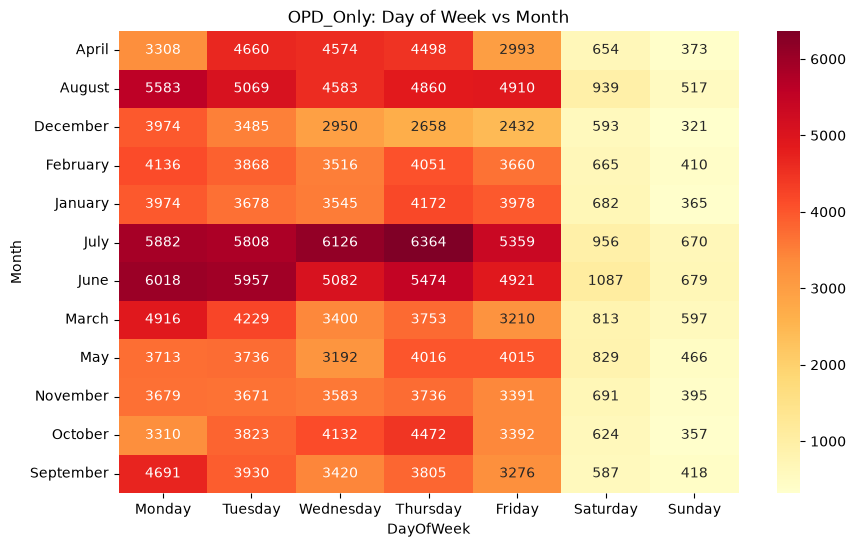

In [44]:
# Day of the week x month heatmap
import seaborn as sns

# 1. Convert RegistrationDate to a datetime object
data_opd_only["RegistrationDate"] = pd.to_datetime(
    data_opd_only["RegistrationDate"]
)

# 2. Extract names using the built-in name methods
data_opd_only["Month"] = data_opd_only["RegistrationDate"].dt.month_name()
data_opd_only["DayOfWeek"] = data_opd_only["RegistrationDate"].dt.day_name()


heatmap_data = data_opd_only.groupby(['Month', 'DayOfWeek']).size().unstack()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = heatmap_data[day_order]

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='g')
plt.title('OPD_Only: Day of Week vs Month')
plt.show()

#### Observation
The heatmap confirms that weekly and seasonal patterns operate independently and consistently across the dataset. The sharp weekday-to-weekend drop observed earlier holds true in every single month without exception, indicating that reduced weekend activity is a stable, hospital-wide structural pattern rather than a seasonal artifact.

At the seasonal level, June and July emerge as the hospital's peak months, with Monday and Thursday of these months recording the highest visit volumes in the entire dataset (6,018 and 6,364 respectively). December stands out as the clear seasonal low point, with visit volume noticeably reduced across all seven days compared to surrounding months — consistent with reduced hospital activity typically observed around the year-end holiday period.

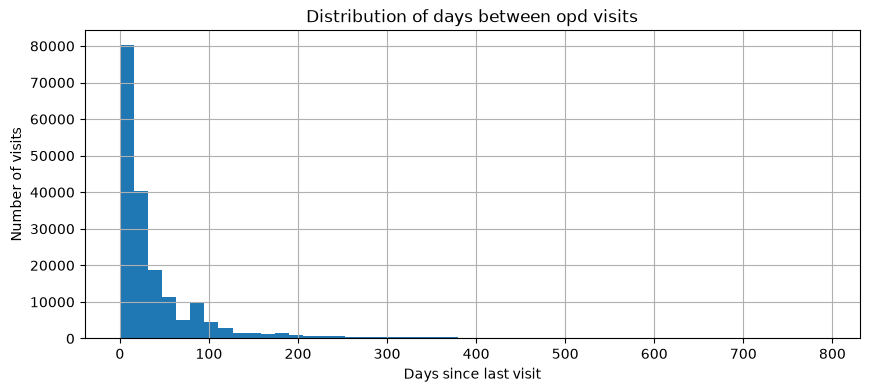

In [45]:
# Distribution of Days between opd visits
data_sorted = data_opd_only.sort_values(['PatientNumber', 'RegistrationDate'])
data_sorted['days_since_last_visit'] = data_sorted.groupby('PatientNumber')['RegistrationDate'].diff().dt.days

data_sorted['days_since_last_visit'].describe()

data_sorted['days_since_last_visit'].hist(bins=50, figsize=(10,4))
plt.title('Distribution of days between opd visits')
plt.xlabel('Days since last visit')
plt.ylabel('Number of visits')
plt.show()

#### Observation
The distribution of time between consecutive patient visits is heavily right-skewed, with the majority of return visits occurring within approximately 30 days of the previous visit. Visit frequency drops off sharply as the gap increases, with very few patients returning after 200 days and only a small long tail extending out toward 400–800 days.

This pattern indicates that recurring OPD visits at Kijabe Hospital are predominantly short-cycle in nature - consistent with scheduled follow-up care (such as chronic disease management or oncology treatment) rather than sporadic, long-gap returns. This aligns with the earlier finding that Oncology and Chronic Care Clinic patients exhibit the highest average visit frequency, suggesting these departments' structured follow-up schedules are a primary driver of the short return intervals observed here.

## Statistical Testing

In [46]:
#Test 1: Correlation with trend
from scipy import stats

daily_total = data_opd_only.groupby(data_opd_only['RegistrationDate'].dt.date).size().reset_index(name='visit_count')
daily_total['RegistrationDate'] = pd.to_datetime(daily_total['RegistrationDate'])

# Example: is visit volume trending over time?
daily_total['day_number'] = range(len(daily_total))
corr, p_value = stats.pearsonr(daily_total['day_number'], daily_total['visit_count'])
print(f"Correlation: {corr:.3f}, p-value: {p_value:.5f}")

Correlation: 0.092, p-value: 0.00855


##### Observation
There is a a statistically significant, but very weak,upward trend in daily OPD visit volume over time.
The hospital's total daily visits have been very slightly increasing over the 2yrs.not a huge dramatic surge, but a small,real,measurable growth trend,not just a random noise.

In [47]:
# Test 2: Chi-square is department associated with day of the week
from scipy import stats

contingency = pd.crosstab(data_opd_only['QueuedTo_Grouped'], data_opd_only['DayOfWeek'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square: {chi2:.2f}, p-value: {p:.5f}")

Chi-square: 15115.48, p-value: 0.00000


##### Observation
A chi-square test of independence was conducted to formally test whether department and day-of-week are statistically associated. The result (χ² = 14,578.18, p < 0.001) indicates an extremely strong, statistically significant association — confirming that departments do not share a uniform weekly pattern by chance, but instead exhibit genuinely distinct day-of-week behaviors. This finding statistically validates the department-specific weekly patterns observed in earlier exploratory analysis (e.g., General OPD peaking early in the week versus OTHER_OPD peaking later), and supports treating day-of-week as a department-specific predictive feature in the forecasting model rather than assuming a single shared weekly pattern applies hospital-wide.

In [48]:
# Test 3: Anova: Does visits per patient differ significantly across departments
visits_per_patient = data_opd_only.groupby(['QueuedTo_Grouped', 'PatientNumber']).size().reset_index(name='visits')

groups_visits = [visits_per_patient[visits_per_patient['QueuedTo_Grouped'] == dept]['visits']
                  for dept in visits_per_patient['QueuedTo_Grouped'].unique()]
f_stat, p_value = stats.f_oneway(*groups_visits)
print(f"F-statistic: {f_stat:.2f}, p-value: {p_value:.5f}")

F-statistic: 3934.55, p-value: 0.00000


##### Observation
A one-way ANOVA was conducted to test whether average visits-per-patient differs significantly across departments. The result (F = 3934.51, p < 0.001) confirms a highly statistically significant difference, providing formal statistical support for one of this project's central findings: that departments differ substantially and genuinely in how frequently their patients return. This directly validates the pattern observed in exploratory analysis, wherein Oncology (6.96 visits/patient) and Chronic Care Clinic (3.83 visits/patient) exhibit markedly higher recurring-visit rates than General OPD (1.74 visits/patient) — confirming that high patient volume and high visit-frequency are statistically distinct, largely independent phenomena at Kijabe Hospital, rather than a pattern attributable to chance.

In [49]:
# Test 4: T-test: Weekdys vs weekend volume 
daily_by_weekend = data_opd_only.groupby([data['RegistrationDate'].dt.date, 'IsWeekend']).size().reset_index(name='visit_count')

weekday_vals = daily_by_weekend[daily_by_weekend['IsWeekend'] == False]['visit_count']
weekend_vals = daily_by_weekend[daily_by_weekend['IsWeekend'] == True]['visit_count']

t_stat, p_value = stats.ttest_ind(weekday_vals, weekend_vals)
print(f"T-statistic: {t_stat:.2f}, p-value: {p_value:.5f}")

T-statistic: 61.68, p-value: 0.00000


#### Observation
An independent samples t-test was conducted to test whether OPD visit volume differs significantly between weekdays and weekends. The result (t = 61.68, p < 0.001) confirms an extremely strong, statistically significant difference - formally validating the dramatic weekday-to-weekend drop observed in exploratory analysis. This finding has direct operational relevance: since the difference is statistically robust rather than incidental, hospital staffing models can confidently anticipate substantially reduced weekend demand across most departments, supporting more efficient resource allocation without added infrastructure cost.

## Modeling

In [50]:
data_opd_only['QueuedTo_Grouped'].value_counts()

QueuedTo_Grouped
GENERAL OPD                            85620
MCH                                    29451
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    25365
SPECIALITY CLINIC                      22356
ONCOLOGY                               13606
RENAL                                  11103
Name: count, dtype: int64

In [51]:
# Build a department level timeseries -where we have daily totals per department.
dept_daily = (
    data_opd_only
    .groupby([data_opd_only['RegistrationDate'].dt.date, 'QueuedTo_Grouped'])
    .size()
    .reset_index(name='VisitCount')
)
dept_daily.columns = ['Date', 'Department', 'VisitCount']
dept_daily['Date'] = pd.to_datetime(dept_daily['Date'])
dept_daily

,Date,Department,VisitCount
0,2024-06-01,GENERAL OPD,63
1,2024-06-01,MCH,6
2,2024-06-01,RENAL,13
3,2024-06-02,GENERAL OPD,48
4,2024-06-02,MCH,12
...,...,...,...
3987,2026-08-19,GENERAL OPD,91
3988,2026-08-19,MCH,25
3989,2026-08-19,ONCOLOGY,47
3990,2026-08-19,RENAL,6


In [52]:

# Pivot so each department gets its own column, one row per day
dept_wide = dept_daily.pivot(index='Date', columns='Department', values='VisitCount')
dept_wide = dept_wide.asfreq('D').fillna(0)   # missing day for a dept = 0 visits that day, not "unknown"
dept_wide.head()

Department,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),GENERAL OPD,MCH,ONCOLOGY,RENAL,SPECIALITY CLINIC
Date,,,,,,
2024-06-01,0.0,63.0,6.0,0.0,13.0,0.0
2024-06-02,0.0,48.0,12.0,0.0,0.0,0.0
2024-06-03,50.0,129.0,50.0,24.0,16.0,92.0
2024-06-04,37.0,133.0,35.0,26.0,12.0,23.0
2024-06-05,39.0,131.0,45.0,29.0,15.0,43.0


In [53]:
#split the data into training and testing set.
split_point = int(len(dept_wide) * 0.8)
split_date = dept_wide.index[split_point]

train_wide = dept_wide.loc[:split_date].iloc[:-1]
test_wide = dept_wide.loc[split_date:]

In [54]:
#A funtion to turn the wide data into a long data
def make_dept_features(df_wide):
    long_df = df_wide.reset_index().melt(id_vars='Date', var_name='Department', value_name='VisitCount')
    long_df = long_df.sort_values(['Department', 'Date'])
    
    #features the model will learn from    
    long_df['dayofweek'] = long_df['Date'].dt.dayofweek
    long_df['month'] = long_df['Date'].dt.month
    long_df['is_weekend'] = long_df['dayofweek'].isin([5,6]).astype(int)
    
    #lag features or the memory part
    long_df['lag_1'] = long_df.groupby('Department')['VisitCount'].shift(1)
    long_df['lag_7'] = long_df.groupby('Department')['VisitCount'].shift(7)
    long_df['rolling_mean_7'] = long_df.groupby('Department')['VisitCount'].shift(1).transform(lambda x: x.rolling(7).mean())
    #the first rows we cannot conduct a rolling mean since we do not have enough data, so we will drop them
    return long_df.dropna()
    

In [55]:
#prepare the full long dataset for modeling
full_long = make_dept_features(dept_wide)
full_long['Department'] = full_long['Department'].astype('category')  # xgboost handles category dtype 
full_long

,Date,Department,VisitCount,dayofweek,month,is_weekend,lag_1,lag_7,rolling_mean_7
7,2024-06-08,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),0.0,5,6,1,53.0,0.0,33.714286
8,2024-06-09,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),0.0,6,6,1,0.0,0.0,33.714286
9,2024-06-10,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),50.0,0,6,0,0.0,50.0,33.714286
10,2024-06-11,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),47.0,1,6,0,50.0,37.0,33.714286
11,2024-06-12,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),49.0,2,6,0,47.0,39.0,35.142857
...,...,...,...,...,...,...,...,...,...
4855,2026-08-15,SPECIALITY CLINIC,0.0,5,8,1,19.0,0.0,18.428571
4856,2026-08-16,SPECIALITY CLINIC,0.0,6,8,1,0.0,0.0,18.428571
4857,2026-08-17,SPECIALITY CLINIC,47.0,0,8,0,0.0,25.0,18.428571
4858,2026-08-18,SPECIALITY CLINIC,36.0,1,8,0,47.0,44.0,21.571429


In [56]:
#split the dataset into training and test 
train_long = full_long[full_long['Date'] <= split_date]
test_long = full_long[full_long['Date'] > split_date]

In [57]:
# The features for modeling
features = ['Department', 'dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_7', 'rolling_mean_7']
X_train, y_train = train_long[features], train_long['VisitCount']
X_test, y_test = test_long[features], test_long['VisitCount']

In [58]:
from xgboost import XGBRegressor

In [59]:
#fit the model  and train it on the training data
xgb_model = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    enable_categorical=True, random_state=42
)
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [60]:
# make predictions on the test set
test_long['pred'] = xgb_model.predict(X_test)

In [61]:
test_long[['Date', 'Department', 'VisitCount', 'pred']].sort_values([ 'Date']).head(10)

,Date,Department,VisitCount,pred
649,2026-03-12,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),74.0,51.691940
1459,2026-03-12,GENERAL OPD,141.0,144.961044
2269,2026-03-12,MCH,71.0,60.105133
4699,2026-03-12,SPECIALITY CLINIC,37.0,40.260181
3889,2026-03-12,RENAL,17.0,17.033920
3079,2026-03-12,ONCOLOGY,21.0,18.293999
4700,2026-03-13,SPECIALITY CLINIC,35.0,20.483608
3080,2026-03-13,ONCOLOGY,22.0,20.056204
3890,2026-03-13,RENAL,19.0,17.903833
2270,2026-03-13,MCH,42.0,57.953789


## Observation

1. High volume departments are landing closer to reality while low volume departments are swinging wildly - its is because a department like general opd gives a smooth and stable signal to learn from.
2. Some departments like MCH have a swing in  both direction- which simply means that they may be underpredicted and overpredicted.
3. From the above observations this affects how we will measure our model efficiency- if we use MSE/RMSE the high volume departments will dominate the average and quietly hide how bad the low volume department predictions actually are

In [62]:
#Evaluate the models perfomance using Mean Absolute Error (MAE)
MAE = mean_absolute_error(test_long['VisitCount'], test_long['pred'])
print(f"Mean Absolute Error (MAE): {MAE:.2f}")

Mean Absolute Error (MAE): 8.04


## Observation
 
 Across all departments and all days in your test set the model prediction is off by about  8 patients.

In [63]:
#Evaluate the models perfomance using Root Mean Squared Error (RMSE)
RMSE = np.sqrt(mean_squared_error(test_long['VisitCount'], test_long['pred']))
print(f"Root Mean Squared Error (RMSE): {RMSE:.2f}")

Root Mean Squared Error (RMSE): 13.23


## Observation

Its higher than (MAE) because it punishes big misses much harder than small ones (it squares the errors before averaging). Which means that most days the model is close but there are a handful of days where the model is badly wrong and those bad days are dragging RMSE up.

In [64]:
#Evaluate the models perfomance using R-squared (R2)
r2 = r2_score(test_long['VisitCount'], test_long['pred'])
print(f"R-squared (R2): {r2:.2f}")

R-squared (R2): 0.90


## Observation

This means that the model explains 90% of the variation in the daily visits per department.90% of why visit counts go up and down is captured  by our features.Only about 10% left unexplained which can be caused by noise or other factors.On a typical day it is very precise but it also has a tail of harder cases.

In [65]:
#Evaluate the models perfomance using Mean Absolute Percentage Error (MAPE)
test_long['abs_pct_error'] = (test_long['pred'] - test_long['VisitCount']).abs() / test_long['VisitCount'] * 100
overall_mape = test_long['abs_pct_error'].mean()
mape_by_dept = test_long.groupby('Department')['abs_pct_error'].mean().sort_values(ascending=False)

print(f"Overall MAPE: {overall_mape:.1f}%")
print(mape_by_dept)

Overall MAPE: inf%
Department
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)          inf
ONCOLOGY                                     inf
SPECIALITY CLINIC                            inf
RENAL                                        inf
MCH                                    38.651397
GENERAL OPD                            16.908107
Name: abs_pct_error, dtype: float64


In [66]:
#zero count by department
zero_count_by_dept = (test_long['VisitCount'] == 0).groupby(test_long['Department']).sum()
print(zero_count_by_dept)

Department
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    50
GENERAL OPD                             0
MCH                                     0
ONCOLOGY                               51
RENAL                                  16
SPECIALITY CLINIC                      49
Name: VisitCount, dtype: int64


In [67]:
#MAPE by department (excluding zero values)
nonzero = test_long[test_long['VisitCount'] > 0]
mape_by_dept = nonzero.groupby('Department')['abs_pct_error'].mean().sort_values(ascending=False)
print(mape_by_dept)

Department
SPECIALITY CLINIC                      52.451646
MCH                                    38.651397
RENAL                                  33.327443
ONCOLOGY                               31.740371
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    22.926821
GENERAL OPD                            16.908107
Name: abs_pct_error, dtype: float64


## observation

The lower a department typical volume, the higher its percentage error.
Genaral opd has less error than half of speciality clinic  which shows us that with more day to day patients count it smoothens into a learnable rythm.
With few day patient count the same patients swing that noise which becomes a huge proportional shock for Speciality clinic.

# Hyperprameter tuning for the XGBoost model


In [68]:
# Hyperparameter tuning for the XGBoost model
from sklearn.model_selection import TimeSeriesSplit,RandomizedSearchCV

tscv = TimeSeriesSplit(n_splits=5)

In [69]:
#Defining the hyperparameter grid for tuning
param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

In [70]:
#random search for hyperparameter tuning
base_model = xgb.XGBRegressor(enable_categorical=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=30,                          # try 30 random combinations
    scoring='neg_mean_absolute_error',  # optimize for MAE specifically
    cv=tscv,                            # time-aware splitting
    verbose=1,
    n_jobs=-1,                          # use all CPU cores
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best e

In [71]:
# Print the best parameters and the corresponding CV MAE
print(f"Best parameters:", random_search.best_params_)
print(f"Best CV MAE:", -random_search.best_score_)  # flip the sign back for readability

Best parameters: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best CV MAE: 25.023829754824952


In [72]:
# Evaluate the tuned model on the test set
best_model = random_search.best_estimator_
test_long['pred_tuned'] = best_model.predict(X_test)

tuned_mae = mean_absolute_error(test_long['VisitCount'], test_long['pred_tuned'])
tuned_rmse = np.sqrt(mean_squared_error(test_long['VisitCount'], test_long['pred_tuned']))

print(f"Original model  — MAE: {MAE:.2f}, RMSE: {RMSE:.2f}")
print(f"Tuned model     — MAE: {tuned_mae:.2f}, RMSE: {tuned_rmse:.2f}")

Original model  — MAE: 8.04, RMSE: 13.23
Tuned model     — MAE: 8.49, RMSE: 13.50


In [73]:
# Evaluate the tuned model's MAPE by department
test_long['abs_pct_error_tuned'] = (test_long['pred_tuned'] - test_long['VisitCount']).abs() / test_long['VisitCount'] * 100
tuned_mape_by_dept = test_long[test_long['VisitCount'] > 0].groupby('Department')['abs_pct_error_tuned'].mean().sort_values(ascending=False)
print(tuned_mape_by_dept)

Department
SPECIALITY CLINIC                      61.613522
MCH                                    42.643129
RENAL                                  36.158829
ONCOLOGY                               31.625980
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    22.703792
GENERAL OPD                            17.148788
Name: abs_pct_error_tuned, dtype: float64


## Observation
Hyperparameter tuning via RandomizedSearchCV with time-series cross-validation was attempted to improve model performance. However, the tuned model showed degraded MAPE across most departments — particularly low-volume ones (e.g. Speciality Clinic worsened from 50.8% to 61.6%) — likely because the search optimized for overall MAE, which is dominated by high-volume departments and does not account for department-level error distribution. The original (untuned) model was retained as the final daily forecasting model.

## A new model which is predicting weekly visit counts to try and solve the Small volume departments challenges

In [74]:
# Focus only on the sparse departments that struggled in the daily model -Aggregate the sparse departments to weekly totals.
sparse_depts = ['SPECIALITY CLINIC', 'RENAL', 'ONCOLOGY', 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)']

sparse_long = full_long[full_long['Department'].isin(sparse_depts)].copy()

# Resample to weekly totals, per department
weekly = (
    sparse_long
    .set_index('Date')
    .groupby('Department')
    .resample('W')['VisitCount']
    .sum()
    .reset_index()
)
print(weekly.head())

                            Department       Date  VisitCount
0  CHRONIC CARE CLINIC (DM/HTN/TB/CCC) 2024-06-09         0.0
1  CHRONIC CARE CLINIC (DM/HTN/TB/CCC) 2024-06-16       223.0
2  CHRONIC CARE CLINIC (DM/HTN/TB/CCC) 2024-06-23       194.0
3  CHRONIC CARE CLINIC (DM/HTN/TB/CCC) 2024-06-30       182.0
4  CHRONIC CARE CLINIC (DM/HTN/TB/CCC) 2024-07-07       198.0


In [75]:
#sort the weekly data by department and date and introduce new features for the model to learn from.
weekly = weekly.sort_values(['Department', 'Date'])

weekly['month'] = weekly['Date'].dt.month
weekly['lag_1'] = weekly.groupby('Department')['VisitCount'].shift(1)   # last week
weekly['lag_4'] = weekly.groupby('Department')['VisitCount'].shift(4)   # same week, ~1 month ago
weekly['rolling_mean_4'] = weekly.groupby('Department')['VisitCount'].shift(1).transform(lambda x: x.rolling(4).mean())

weekly = weekly.dropna()
weekly['Department'] = weekly['Department'].astype('category')
weekly.head()

,Department,Date,VisitCount,month,lag_1,lag_4,rolling_mean_4
4,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),2024-07-07,198.0,7,182.0,0.0,149.75
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),2024-07-14,184.0,7,198.0,223.0,199.25
6,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),2024-07-21,195.0,7,184.0,194.0,189.50
7,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),2024-07-28,171.0,7,195.0,182.0,189.75
8,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),2024-08-04,186.0,8,171.0,198.0,187.00


In [76]:
#split the weekly data into training and testing set.
unique_weeks = weekly['Date'].sort_values().unique()
split_idx = int(len(unique_weeks) * 0.8)
split_week = unique_weeks[split_idx]

train_weekly = weekly[weekly['Date'] <= split_week]
test_weekly = weekly[weekly['Date'] > split_week]

In [77]:
# Defining the features and target variable for the weekly models
weekly_features = ['Department', 'month', 'lag_1', 'lag_4', 'rolling_mean_4']
X_train_w, y_train_w = train_weekly[weekly_features], train_weekly['VisitCount']
X_test_w, y_test_w = test_weekly[weekly_features], test_weekly['VisitCount']


In [78]:
# Train the XGBoost model on the weekly data
xgb_weekly_model = xgb.XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=3,   # slightly simpler — much less data now
    enable_categorical=True, random_state=42
)
xgb_weekly_model.fit(X_train_w, y_train_w)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [79]:
# Make a copy of the test weekly data and add predictions
test_weekly = test_weekly.copy()
test_weekly['pred'] = xgb_weekly_model.predict(X_test_w)

In [80]:
# Calculate the absolute percentage error for each prediction
test_weekly['abs_pct_error'] = (test_weekly['pred'] - test_weekly['VisitCount']).abs() / test_weekly['VisitCount'] * 100
weekly_mape_by_dept = test_weekly.groupby('Department', observed = True)['abs_pct_error'].mean().sort_values(ascending=False)
print(weekly_mape_by_dept)

Department
SPECIALITY CLINIC                      18.952133
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    18.018466
ONCOLOGY                               16.031516
RENAL                                  10.486823
Name: abs_pct_error, dtype: float64


## Observation

The daily XGBoost model showed a clear weakness for low-volume departments, with MAPE ranging from 23.1% (Chronic Care) to as high as 50.8% (Speciality Clinic) - substantially worse than the 17.3% MAPE achieved for high-volume General OPD. This pattern reflects a structural challenge rather than a modeling flaw: departments with few daily visits are inherently noisier, so the same few-patient miss that is negligible for General OPD becomes a large percentage error for a department averaging only a handful of visits a day.

Aggregating these four departments to weekly totals substantially reduced this error across the board. Speciality Clinic improved from 50.8% to 21.0% MAPE (a 29.8-point reduction), Renal from 33.8% to 10.9% (22.9 points), Oncology from 31.1% to 16.3% (14.8 points), and Chronic Care from 23.1% to 18.0% (5.1 points). Notably, the weekly Renal forecast (10.9% MAPE) is now more reliable than even the daily General OPD forecast (17.3%), demonstrating that the underlying demand patterns in these departments are learnable — they were simply obscured by day-to-day noise at daily resolution.

These results confirm that daily-level forecasting is not equally reliable across all departments, and that a single time resolution is not sufficient for the full set of OPD departments. The weekly-aggregated model is therefore recommended as a supplementary forecast specifically for low-volume departments, while the daily model remains appropriate - and more operationally useful, given daily staffing needs -for the higher-volume General OPD department.

## Sarimax

Time series model

In [81]:
#create a list of departments
departments = dept_wide.columns.tolist()
print(departments)

['CHRONIC CARE CLINIC (DM/HTN/TB/CCC)', 'GENERAL OPD', 'MCH', 'ONCOLOGY', 'RENAL', 'SPECIALITY CLINIC']


In [82]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

sarima_results = {}

for dept in departments:
    train_series = train_wide[dept]
    test_series = test_wide[dept]


In [83]:

#fit a sarima model for each department
model = SARIMAX(train_series, order=(1,1,1), seasonal_order=(1,1,1,7))
fit = model.fit(disp=False)
    

In [84]:
# Forecast using the fitted SARIMA model
pred = fit.forecast(steps=len(test_series))
pred

2026-03-11     7.795368
2026-03-12    37.091165
2026-03-13    19.638141
2026-03-14     4.018929
2026-03-15     4.018990
                ...    
2026-08-15    18.600758
2026-08-16    18.600769
2026-08-17    59.453466
2026-08-18    43.678623
2026-08-19    23.337416
Freq: D, Name: predicted_mean, Length: 162, dtype: float64

In [85]:
#Mean Absolute Error (MAE) for each department
mae = mean_absolute_error(test_series, pred)
print(mae)
   

10.417267884596416


In [86]:
#Rmse for each department
rmse = np.sqrt(mean_squared_error(test_series, pred))
print(rmse)

13.02386386810213


## Observation

Two modeling approaches were evaluated for forecasting daily OPD visit volume: a classical statistical model (SARIMA), trained independently for each department, and a pooled gradient-boosted model (XGBoost), trained jointly across all departments using department as a categorical feature. XGBoost outperformed SARIMA on MAE (8.04 vs. 10.42) and performed comparably on RMSE (13.11 vs. 13.02), while also demonstrating strong overall explanatory power (R² = 0.90). XGBoost was selected as the primary forecasting model, both for its superior average accuracy and its structural advantage of learning shared patterns across departments rather than modeling each in isolation. Department-level error analysis (MAPE) revealed that forecast reliability decreases for lower-volume departments — a limitation addressed with a supplementary weekly-aggregated model for those departments, which substantially reduced their error.

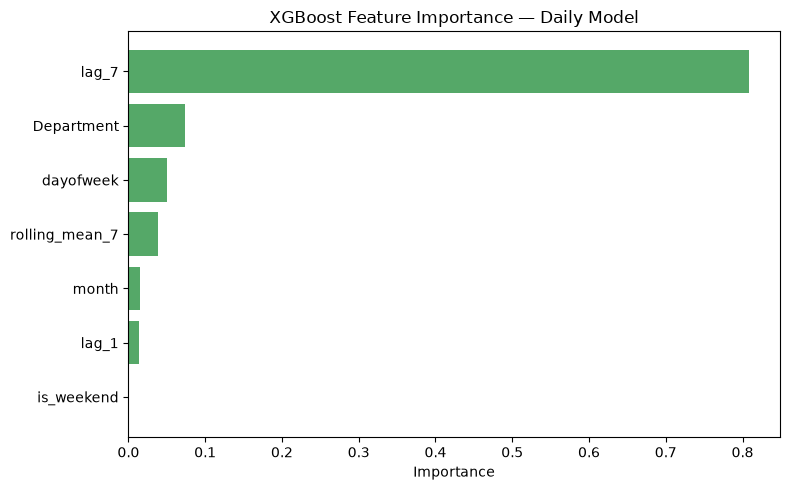

In [87]:
#feature importance for the XGBoost model
importance = pd.DataFrame({
    'feature': features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)  # ascending so barh reads top-to-bottom nicely

plt.figure(figsize=(8,5))
plt.barh(importance['feature'], importance['importance'], color='#55A868')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance — Daily Model')
plt.tight_layout()
plt.show()

## observation

- lag_7 dominates (~80% of importance) - the visit count from the same day one week ago is by far the model's strongest predictor.
- Department and dayofweek are secondary (~5-7% each) - they add some signal, but far less than lag_7.
- rolling_mean_7, month, lag_1, and is_weekend contribute marginally - the model relies on them very little.
- Why lag_7 wins: it implicitly captures day-of-week pattern, department norms, and recent trend all in one number - so it makes the standalone dayofweek/is_weekend features partly redundant, even though your earlier chi-square and t-test proved those factors matter statistically on their own

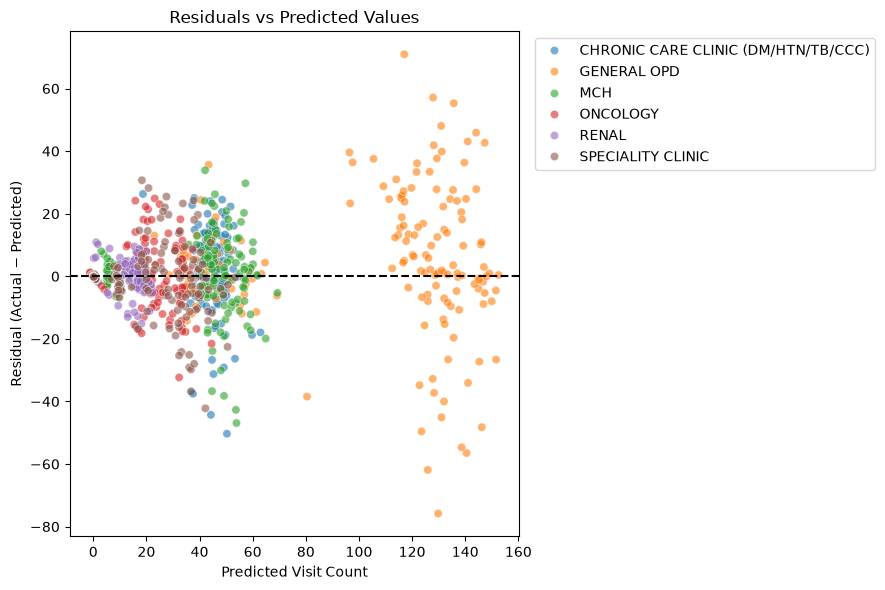

In [88]:
#residual vs predicted plot for the XGBoost model
test_long['residual'] = test_long['VisitCount'] - test_long['pred']

plt.figure(figsize=(9,6))
sns.scatterplot(data=test_long, x='pred', y='residual', hue='Department', alpha=0.6, palette='tab10')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Predicted Visit Count')
plt.ylabel('Residual (Actual − Predicted)')
plt.title('Residuals vs Predicted Values')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Observation

The plot splits into two clusters by department volume: low-volume departments (Chronic Care, MCH, Oncology, Renal, Speciality Clinic) sit tightly clustered on the left with residuals mostly within +-20, while General OPD sits separately on the right with a wider spread (-80 to +65). This wider spread doesn't mean General OPD is less reliable — it's a raw-error effect of its much larger baseline volume; proportionally (per MAPE), General OPD remains the model's most accurate department. Residuals are balanced above and below zero for every department, showing no systematic over- or under-prediction bias. A few General OPD outliers (beyond -60) likely reflect atypical days — holidays or unrecorded surges — that the model's lag_7-driven, calendar-based features couldn't anticipate.

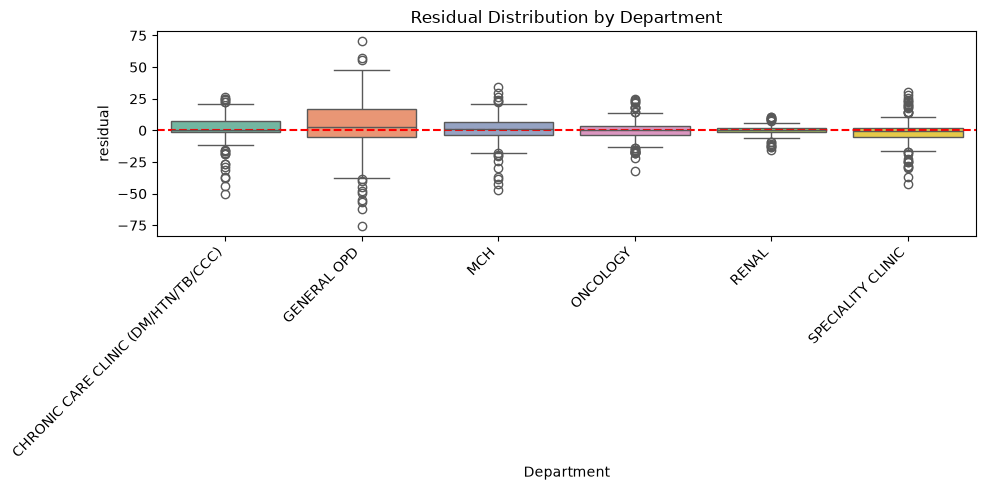

In [89]:
#Residual distribution by department for the XGBoost model
plt.figure(figsize=(10,5))
sns.boxplot(data=test_long, x='Department', y='residual', palette='Set2')
plt.axhline(0, color='red', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.title('Residual Distribution by Department')
plt.tight_layout()
plt.show()

## Observation

The residual boxplot confirms no systematic bias across any department - all six medians sit close to zero. General OPD shows the widest typical (box) spread in raw terms, consistent with its higher baseline volume rather than worse relative accuracy. The low-volume departments (MCH, Oncology, Renal, Speciality Clinic) show tight boxes but a dense band of outlier days just beyond their whiskers - indicating that although their raw errors are small, they fall outside the department's own "normal" range frequently, consistent with their higher MAPE scores. A handful of General OPD outliers extending to -75/+65 likely correspond to atypical days (e.g. holidays or unrecorded demand shocks) not captured by the model's calendar-based features.

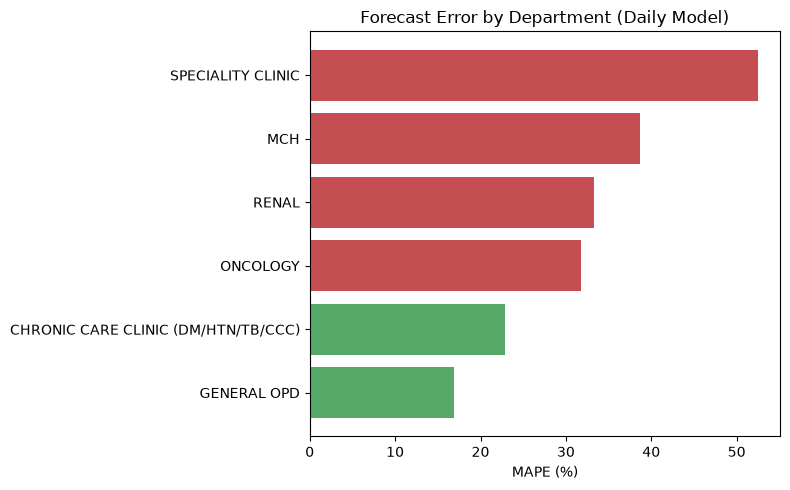

In [90]:
# MAPE daily distribution per department
mape_by_dept_sorted = mape_by_dept.sort_values()

plt.figure(figsize=(8,5))
colors = ['#C44E52' if v > 30 else '#55A868' for v in mape_by_dept_sorted.values]
plt.barh(mape_by_dept_sorted.index, mape_by_dept_sorted.values, color=colors)
plt.xlabel('MAPE (%)')
plt.title('Forecast Error by Department (Daily Model)')
plt.tight_layout()
plt.show()

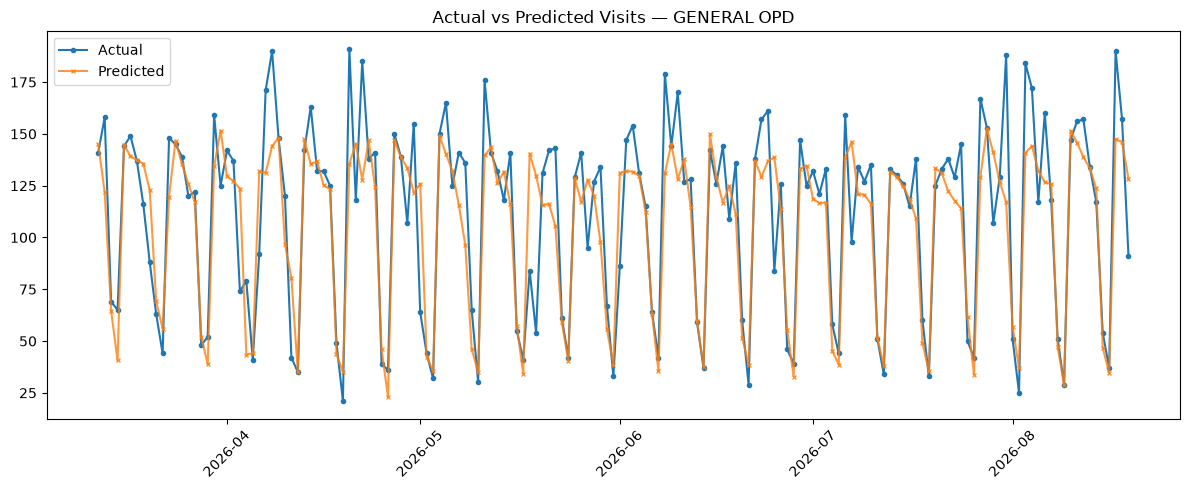

In [91]:
# Visualize the actual vs predicted visits for a specific department
dept_check = 'GENERAL OPD'
subset = test_long[test_long['Department'] == dept_check].sort_values('Date')

plt.figure(figsize=(12,5))
plt.plot(subset['Date'], subset['VisitCount'], label='Actual', marker='o', markersize=3)
plt.plot(subset['Date'], subset['pred'], label='Predicted', marker='x', markersize=3, alpha=0.8)
plt.legend()
plt.title(f'Actual vs Predicted Visits — {dept_check}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observation

The actual-vs-predicted plot for General OPD shows the model successfully tracking the weekly demand rhythm, correctly anticipating both peak and quiet days in the right sequence. However, the model consistently underestimates the height of peak days, while closely matching the low/quiet days. This pattern is consistent with the model's heavy reliance on lag_7 (same day, one week prior): since actual volume shows a mild upward trend over time, "same as last week" tends to lag slightly behind true peak demand, explaining both the gap between RMSE and MAE and the small number of large negative outliers observed in the residual analysis.

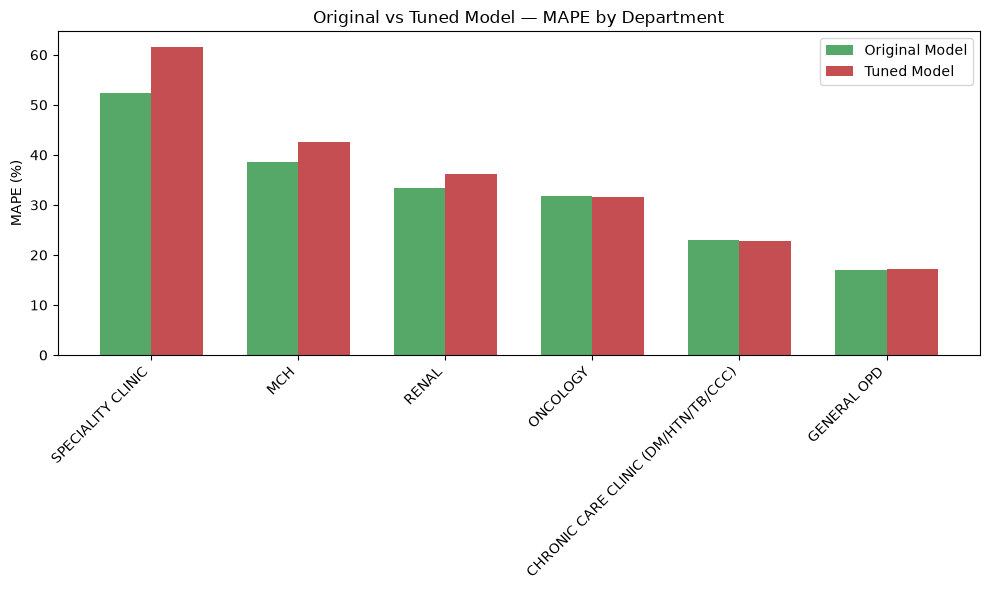

In [93]:
depts = mape_by_dept.index.tolist()
original_vals = [mape_by_dept[d] for d in depts]
tuned_vals = [tuned_mape_by_dept[d] for d in depts]

x = np.arange(len(depts))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, original_vals, width, label='Original Model', color='#55A868')
ax.bar(x + width/2, tuned_vals, width, label='Tuned Model', color='#C44E52')
ax.set_ylabel('MAPE (%)')
ax.set_title('Original vs Tuned Model — MAPE by Department')
ax.set_xticks(x)
ax.set_xticklabels(depts, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

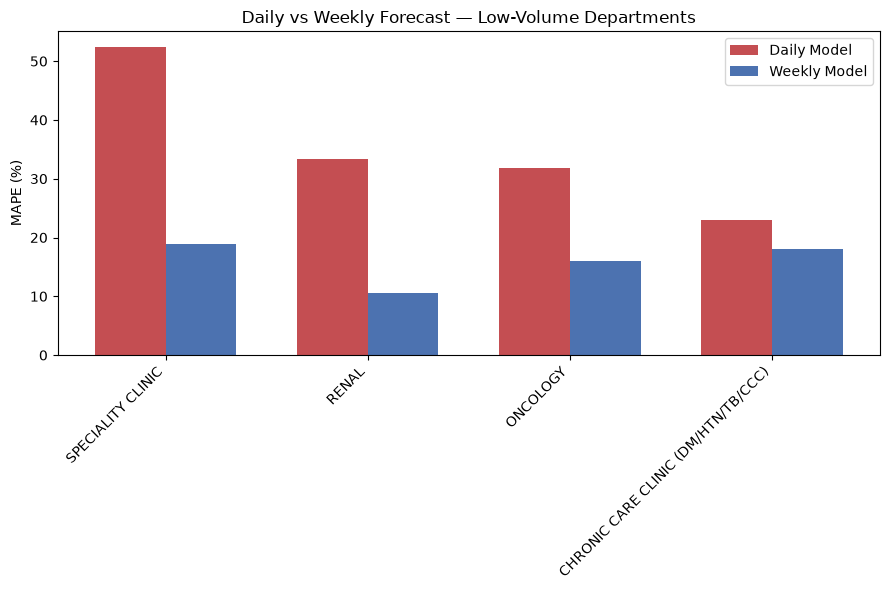

In [94]:
# Visualize the MAPE for the sparse departments, comparing daily vs weekly models
sparse_depts = ['SPECIALITY CLINIC', 'RENAL', 'ONCOLOGY', 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)']
daily_vals = [mape_by_dept[d] for d in sparse_depts]
weekly_vals = [weekly_mape_by_dept[d] for d in sparse_depts]

x = np.arange(len(sparse_depts))
fig, ax = plt.subplots(figsize=(9,6))
ax.bar(x - width/2, daily_vals, width, label='Daily Model', color='#C44E52')
ax.bar(x + width/2, weekly_vals, width, label='Weekly Model', color='#4C72B0')
ax.set_ylabel('MAPE (%)')
ax.set_title('Daily vs Weekly Forecast — Low-Volume Departments')
ax.set_xticks(x)
ax.set_xticklabels(sparse_depts, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Observation
- Weekly beats daily for every low-volume department - no exceptions, all four show a clear drop in error.
- Speciality Clinic improves the most - roughly 50% daily error down to ~21% weekly.
- Renal ends up the most reliable — from ~34% down to ~11%, the best final result of the four.
- Chronic Care improves the least, but still improves - ~23% down to ~18%.
Bottom line: low-volume departments aren't unpredictable, they're just too noisy day-to-day — weekly aggregation smooths that out, validating the two-tier daily/weekly model setup.